<a href="https://colab.research.google.com/github/Wai-Fun/Healthcare_Data_Analytics_and_Data_Science/blob/main/Predictive_Models_Decision_Trees_and_Random_Forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building Predictive Models with Decision Trees and Random Forests

## Overview
This project uses decision trees and random forests to solve a clinical prediction problem. Decision trees create simple rule-based predictions, while random forests combine many trees to improve accuracy and reduce overfitting. These models are widely used in healthcare because they work well with tabular data and are easy to interpret.

The project covers the full workflow: data preparation, model training, tuning, evaluation, and interpretation

## Objectives
- Understand decision trees and random forests and when to use them.
- Prepare clinical data (handle missing values and encoding).
- Train and tune models using scikit-learn.
- Evaluate models using accuracy, ROC-AUC, precision, and recall.
- Interpret results using feature importance and basic visualizations.
- Understand limitations and clinical use cases.

## About then Dataset
A simulated clinical dataset is used for a binary prediction task (e.g., readmission or deterioration). The data includes common clinical features, both numerical and categorical, and may contain missing values. The goal is to predict a yes/no outcome and practice building and evaluating machine learning models in a healthcare setting.

##0. Setup

In [ ]:
# Install required libraries quietly (useful in Colab environments)
!pip -q install numpy pandas scikit-learn matplotlib seaborn joblib

In [ ]:
# Import numerical computing library
import numpy as np

# Import data manipulation library
import pandas as pd

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import model selection utilities
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Import tree-based models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)

# Import preprocessing utilities
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Import pipeline tools
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Import model interpretation tools
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

# Import utility for saving models
import joblib

In [ ]:
# Load the dataset from a remote GitHub URL
df = pd.read_csv('https://statistical-analysis-and-data-modeling-in-healthcare-02a43a.gitlab.io/labs/lab5/deterioration_data.csv')

# Display the first five rows of the dataset
df.head()

,patient_id,age,sex,hr_mean,sbp_mean,comorbidity_count,lab_flag,prior_adm,event
0,P20000,71,F,NaN,138.163213,2,1,0,1
1,P20001,63,F,60.030640,130.274935,4,0,1,0
2,P20002,74,M,94.358748,NaN,2,1,0,1
3,P20003,86,F,74.356487,130.743826,1,0,1,0
4,P20004,61,M,NaN,149.396461,2,1,0,1


##1. Inspect and preprocess the data

In [ ]:
# Print number of rows and columns
print('Rows, Columns:', df.shape)

Rows, Columns: (3000, 9)


In [ ]:
# Display data types of all columns
df.dtypes

,0
patient_id,object
age,int64
sex,object
hr_mean,float64
sbp_mean,float64
comorbidity_count,int64
lab_flag,int64
prior_adm,int64
event,int64


In [ ]:
# Show descriptive statistics for numeric variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,3000.0,64.859667,13.597829,19.0,56.000000,65.000000,74.000000,95.000000
hr_mean,2898.0,77.863221,12.484105,40.0,69.462931,77.618635,86.440857,120.348662
sbp_mean,2905.0,124.918330,14.486022,70.0,115.124259,124.990873,134.600399,175.666524
comorbidity_count,3000.0,2.089333,1.463808,0.0,1.000000,2.000000,3.000000,8.000000
lab_flag,3000.0,0.171333,0.376863,0.0,0.000000,0.000000,0.000000,1.000000
prior_adm,3000.0,0.973667,0.979435,0.0,0.000000,1.000000,2.000000,7.000000
event,3000.0,0.112000,0.315419,0.0,0.000000,0.000000,0.000000,1.000000


In [ ]:
# Display class counts for the outcome variable
print('\nEvent counts:\n', df['event'].value_counts())


Event counts:
 event
0    2664
1     336
Name: count, dtype: int64


In [ ]:
# Check for missing values in each column
print(df.isna().sum())

patient_id             0
age                    0
sex                    0
hr_mean              102
sbp_mean              95
comorbidity_count      0
lab_flag               0
prior_adm              0
event                  0
dtype: int64


In [ ]:
#Check for duplicate
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
2995,False
2996,False
2997,False
2998,False


##2. Define preprocessing and pipeline
Note: Tree-based models can work with mixed data types but do not accept missing values. To prepare the data, impute missing numeric values using the median.

In [ ]:
# Define categorical feature columns
categorical_features = ['sex','lab_flag']

In [ ]:
# Define numeric feature columns
numeric_features = ['age','hr_mean','sbp_mean','comorbidity_count','prior_adm']

In [ ]:
# Create numeric preprocessing pipeline with median imputation
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

In [ ]:
# Create categorical preprocessing pipeline with one-hot encoding
categorical_transformer = Pipeline(
    steps=[
        ('onehot', OneHotEncoder())
    ]
)

In [ ]:
# Combine numeric and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## Train/ test split

In [ ]:
# Separate predictors and outcome
X = df.drop(columns=['patient_id','event'])
y = df['event']

In [ ]:
# Split data into training and test sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25, random_state=42
)

In [ ]:
# Print training data shape
print('Training shape:', X_train.shape)

Training shape: (2250, 7)


##3. Train decision tree and evaluate

In [ ]:
# Create a pipeline with preprocessing and decision tree classifier
dt_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('clf', DecisionTreeClassifier(max_depth=6, random_state=42))
    ]
)


In [ ]:
# Train the decision tree model
dt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'hr_mean', 'sbp_mean',
                                                   'comorbidity_count',
                                                   'prior_adm']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder())]),
                                                  ['sex', 'lab_flag'])])),
                ('clf', DecisionTreeClassifier(max_depth=6, random_state=42))])

In [ ]:
# Predict probabilities for the positive class
y_prob_dt = dt_pipeline.predict_proba(X_test)[:,1]

In [ ]:
# Compute and print AUC score
print('Decision Tree AUC:', round(roc_auc_score(y_test, y_prob_dt),3))

Decision Tree AUC: 0.629


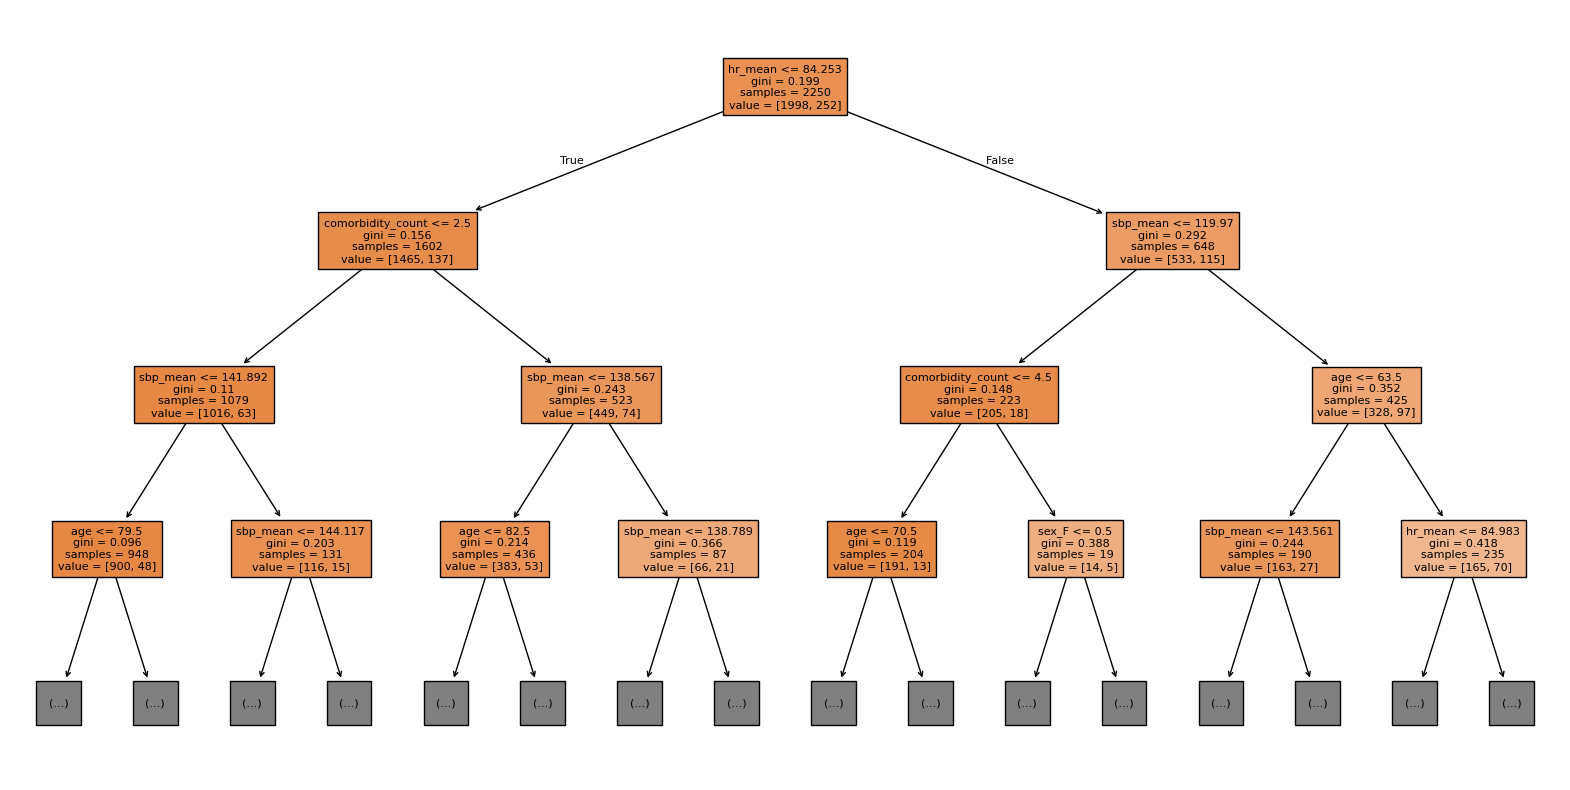

In [ ]:
#Visualize decision tree

# Create a large figure for readability
plt.figure(figsize=(20,10))

# Extract numeric feature names
num_feats = list(preprocessor.transformers_[0][2])

# Extract one-hot encoded feature names
ohe_feats = list(
    dt_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(['sex','lab_flag'])
)

# Combine all feature names
feature_names = num_feats + ohe_feats

# Plot a shallow version of the decision tree
plot_tree(
    dt_pipeline.named_steps['clf'],
    feature_names=feature_names,
    max_depth=3,
    filled=True,
    fontsize=8
)

# Display the plot
plt.show()


##4. Train random forest and evaluate
Random forests reduce overfitting by averaging predictions from many decision trees.

In [ ]:
# Create a pipeline with preprocessing and random forest classifier
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('clf', RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [ ]:
# Train the random forest model
rf_pipeline.fit(X_train, y_train)

# Predict probabilities for the positive class
y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

# Compute and print AUC score
print('Random Forest AUC:', round(roc_auc_score(y_test, y_prob_rf),3))

Random Forest AUC: 0.669


In [ ]:
# Feature importances
# Get feature names
num_feats = list(preprocessor.transformers_[0][2])
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feats = list(ohe.get_feature_names_out(['sex','lab_flag']))

feature_names = num_feats + cat_feats
importances = rf_pipeline.named_steps['clf'].feature_importances_

feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
feat_imp.head(10)

,feature,importance
2,sbp_mean,0.277347
1,hr_mean,0.275509
0,age,0.211680
3,comorbidity_count,0.104517
4,prior_adm,0.066448
6,sex_M,0.018621
5,sex_F,0.018617
7,lab_flag_0,0.015142
8,lab_flag_1,0.012120


##5. Hyperparameter tuning with GridSearchCV- for Random Forest

In [ ]:
# Define grid of hyperparameters to search
param_grid = {
    'clf__n_estimators': [5,50],  #number of trees
    'clf__max_depth': [None, 6, 12],  # How deep the tree grow, depending on total rows of dataset
    'clf__max_features': ['sqrt', 0.5] #how many features sqrt9=3; 0.5 x 9 = 4.5 (4 or 5 features)
}

In [ ]:
# Create GridSearchCV object
grid = GridSearchCV(
    rf_pipeline,  # model I want to tune
    param_grid,   # the hyperparameters
    cv=3,     # number of fold cross-validation
    scoring='roc_auc', # choose model with the best roc_auc
    n_jobs=-1 # use all available cpu scores
)

In [ ]:
# Fit grid search on training data
grid.fit(X_train, y_train)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['age',
                                                                          'hr_mean',
                                                                          'sbp_mean',
                                                                          'comorbidity_count',
                                                                          'prior_adm']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder())]),
                                                                         ['sex',
                                                                          'lab_flag'])])),
                                       ('clf',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__max_depth': [None, 6, 12],
                         'clf__max_features': ['sqrt', 0.5],
                         'clf__n_estimators': [5, 50]},
             scoring='roc_auc')

In [ ]:
# Print best hyperparameters
print('Best params:', grid.best_params_)

Best params: {'clf__max_depth': 6, 'clf__max_features': 0.5, 'clf__n_estimators': 50}


In [ ]:
# Extract best model
best_rf = grid.best_estimator_


In [ ]:
# Predict probabilities with tuned model
y_prob_best = best_rf.predict_proba(X_test)[:,1]


In [ ]:
# Compute and print AUC
print('Best RF AUC:', round(roc_auc_score(y_test, y_prob_best),3))

Best RF AUC: 0.719


In [ ]:
'''
# Save the final model
joblib.dump(best_rf, 'clinical_rf_model.pkl')

loaded_model = joblib.load('clinical_rf_model.pkl')
'''

##6. Interpretation-Feature importance (which feature matter) and partial dependence plot (how they matter)

['sbp_mean', 'hr_mean', 'age', 'comorbidity_count', 'prior_adm']


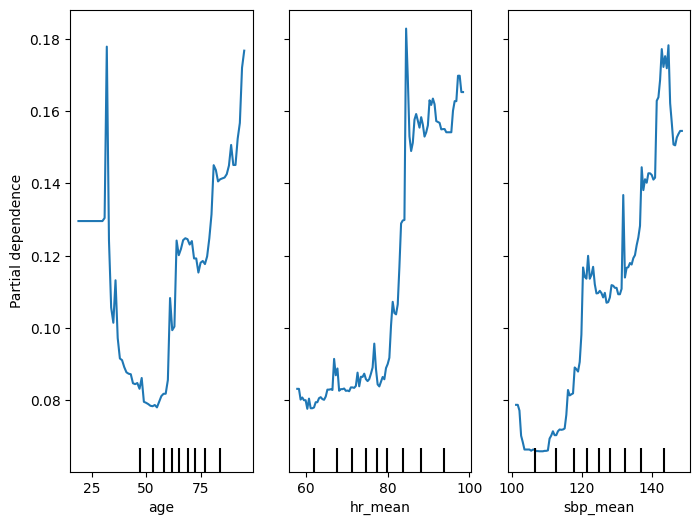

In [ ]:
# Select top 5 most important features
top_feats = feat_imp['feature'].head(5).tolist()
print (top_feats)

# Create a figure for PDP
fig, ax = plt.subplots(figsize=(8,6))

# Generate partial dependence plot (simplified demo)
PartialDependenceDisplay.from_estimator(
    best_rf.named_steps['clf'],
    best_rf.named_steps['preprocessor'].transform(X_train),
    features=[0, 1, 2,],  # plot for first 3 important feature
    feature_names=feature_names,
    ax=ax
)

# Display the plot
plt.show()


##7. Evaluation, calibration and model selection

In [36]:
# Important Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.888
Precision: 0.0
Recall: 0.0
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       666
           1       0.00      0.00      0.00        84

    accuracy                           0.89       750
   macro avg       0.44      0.50      0.47       750
weighted avg       0.79      0.89      0.84       750



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

#### Note on Evaluation Metrics:
Despite achieving a high accuracy (0.888), the model failed to identify any positive cases (recall = 0.0). This is due to significant class imbalance in the dataset, where the majority class dominates the learning objective. As a result, the model defaults to predicting the negative class for all observations.

This highlights why accuracy is not a reliable metric in imbalanced clinical prediction problems. In healthcare settings, recall (sensitivity) is often more important than overall accuracy, as failing to detect at-risk patients can have serious consequences.

Future improvements include using class weighting, adjusting decision thresholds, and optimizing for precision-recall AUC instead of accuracy.

In [ ]:
# Compare baseline and tuned Random Forest performance
print('Baseline RF AUC:', round(roc_auc_score(y_test, y_prob_rf),3))
print('Tuned RF AUC:', round(roc_auc_score(y_test, y_prob_best),3))

Baseline RF AUC: 0.669
Tuned RF AUC: 0.719


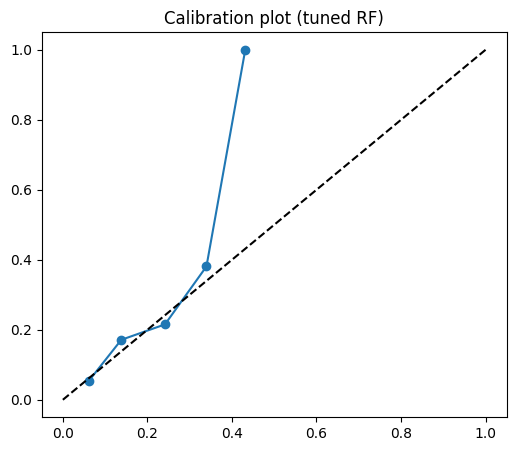

In [ ]:
# Import calibration function
from sklearn.calibration import calibration_curve

# Compute calibration curve values
prob_true, prob_pred = calibration_curve(
    y_test, y_prob_best, n_bins=10
)

# Plot calibration curve
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'k--')
plt.title('Calibration plot (tuned RF)')
plt.show()


The model demonstrates moderate discrimination (AUC = 0.669), but predictions for the positive class are less certain due to the relatively small number of event cases and reduced calibration performance in the highest-risk region.

### Conclusion:
This project compared Decision Tree and Random Forest classifiers for predicting clinical deterioration using a simulated healthcare dataset.

After preprocessing the data with median imputation and one-hot encoding, both models were evaluated using ROC-AUC. The Random Forest slightly outperformed the Decision Tree, consistent with its ensemble structure and reduced variance.

Hyperparameter tuning using GridSearchCV resulted in a modest improvement in discrimination performance, achieving a test ROC-AUC of approximately 0.67.

Feature importance analysis indicated that physiological measurements and comorbidity burden were among the strongest predictors of deterioration.

Although the model demonstrated moderate predictive ability, calibration analysis and threshold-based evaluation revealed limitations in identifying high-risk patients, particularly within the minority class. This is reflected in the low sensitivity for positive cases.

In clinical applications, failing to detect positive cases (false negatives) is often more critical than false positives, highlighting the importance of recall-oriented evaluation in healthcare settings.

Overall, this project demonstrates an end-to-end machine learning workflow for a healthcare prediction problem, including data preprocessing, model development, hyperparameter tuning, evaluation, and interpretation.